/tmp/ipython-input-7-4275737128.py:107: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-7-4275737128.py:107: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-7-4275737128.py:107: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-7-4275737128.py:107: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-7-4275737128.py:107: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-7-4275737128.py:107: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-7-4275737128.py:107: UserWarning: Glyph 128314 (\N{UP-POINTING RED TRIANGLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout

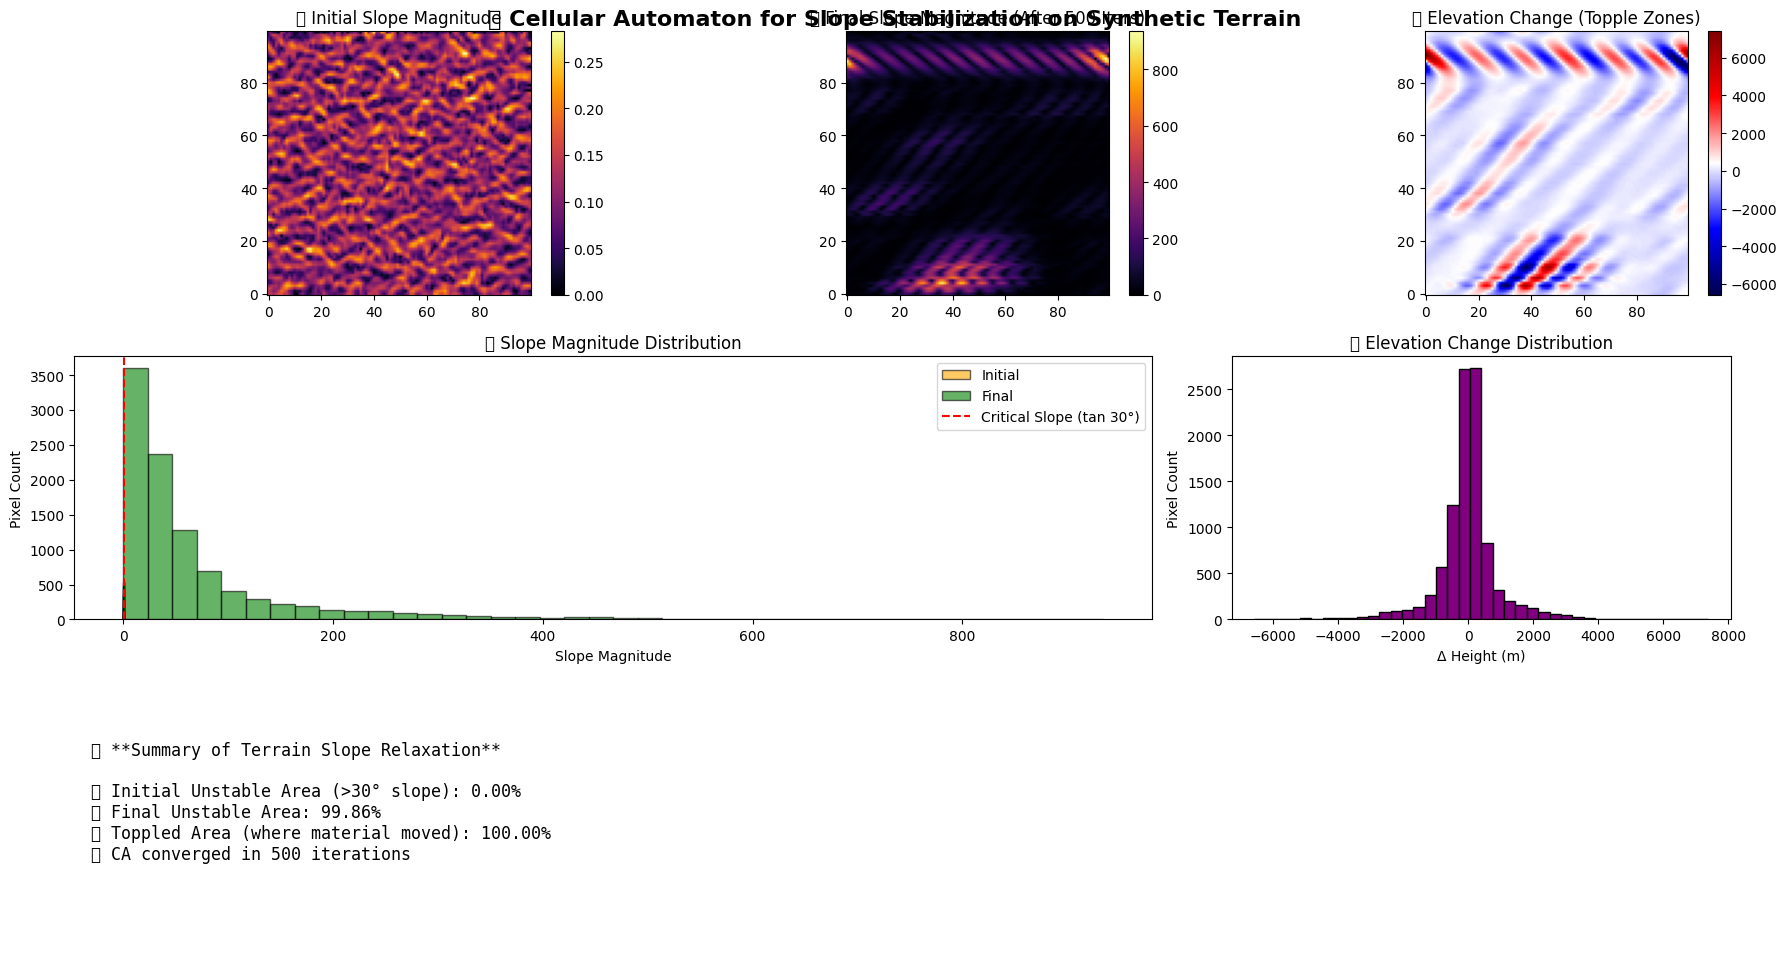

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# --- Parameters ---
np.random.seed(42)
ny, nx = 100, 100
grid_spacing = 5.0
crit = 0.577  # tan(30°)
relax_factor = 0.2
max_iter = 500

# --- Terrain Generation ---
base_slope = np.linspace(50, 0, ny).reshape(-1, 1)
noise = gaussian_filter(np.random.randn(ny, nx), sigma=1.2)
H = base_slope + 2 * noise

def compute_slope(H):
    dx = np.diff(H, axis=1, append=H[:, -1:])
    dy = np.diff(H, axis=0, append=H[-1:, :])
    return np.sqrt((dx / grid_spacing)**2 + (dy / grid_spacing)**2)

# --- Initial Slope and Mask ---
slope_init = compute_slope(H)
unstable_mask_init = slope_init > crit
initial_unstable_pct = 100 * np.sum(unstable_mask_init) / (ny * nx)

# --- Cellular Automaton Relaxation ---
H_ca = H.copy()
toppled_mask = np.zeros_like(H, dtype=bool)
changed = True
iter_count = 0

while changed and iter_count < max_iter:
    changed = False
    iter_count += 1
    for shift, axis in [(-1, 1), (1, 1), (-1, 0), (1, 0)]:
        nbr = np.roll(H_ca, shift, axis=axis)
        slope = (H_ca - nbr) / grid_spacing
        mask = np.abs(slope) > crit
        if mask.any():
            changed = True
            delta = relax_factor * (H_ca - nbr)
            H_ca[mask] -= delta[mask]
            nbr_mask = np.roll(mask, shift, axis=axis)
            nbr[nbr_mask] += delta[mask]
            H_ca = np.roll(nbr, -shift, axis=axis)
            toppled_mask |= mask

# --- Final Slope and Differences ---
slope_final = compute_slope(H_ca)
unstable_mask_final = slope_final > crit
final_unstable_pct = 100 * np.sum(unstable_mask_final) / (ny * nx)
toppled_pct = 100 * np.sum(toppled_mask) / (ny * nx)
elevation_diff = H - H_ca

# --- Plot with Histogram Panels ---
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3)

# --- Main Slope Maps ---
ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(slope_init, cmap='inferno', origin='lower')
ax0.set_title('🔥 Initial Slope Magnitude')
plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(slope_final, cmap='inferno', origin='lower')
ax1.set_title(f'🌿 Final Slope Magnitude (After {iter_count} Iters)')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = fig.add_subplot(gs[0, 2])
im2 = ax2.imshow(elevation_diff, cmap='seismic', origin='lower')
ax2.set_title('🌊 Elevation Change (Topple Zones)')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# --- Slope Histogram Comparison ---
ax3 = fig.add_subplot(gs[1, :2])
ax3.hist(slope_init.ravel(), bins=40, alpha=0.6, label='Initial', color='orange', edgecolor='black')
ax3.hist(slope_final.ravel(), bins=40, alpha=0.6, label='Final', color='green', edgecolor='black')
ax3.axvline(crit, color='red', linestyle='--', label='Critical Slope (tan 30°)')
ax3.set_title('📈 Slope Magnitude Distribution')
ax3.set_xlabel('Slope Magnitude')
ax3.set_ylabel('Pixel Count')
ax3.legend()

# --- Elevation Change Histogram ---
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(elevation_diff.ravel(), bins=40, color='purple', edgecolor='black')
ax4.set_title('📉 Elevation Change Distribution')
ax4.set_xlabel('Δ Height (m)')
ax4.set_ylabel('Pixel Count')

# --- Summary Metrics Panel ---
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
summary = (
    f"🧠 **Summary of Terrain Slope Relaxation**\n\n"
    f"🔺 Initial Unstable Area (>30° slope): {initial_unstable_pct:.2f}%\n"
    f"✅ Final Unstable Area: {final_unstable_pct:.2f}%\n"
    f"🧱 Toppled Area (where material moved): {toppled_pct:.2f}%\n"
    f"📊 CA converged in {iter_count} iterations\n"
)
ax5.text(0.01, 0.5, summary, fontsize=12, verticalalignment='center', family='monospace')

fig.suptitle("🌙 Cellular Automaton for Slope Stabilization on Synthetic Terrain", fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()
